# Kinematic Alternatives and Style EDA

This notebook is for:

1. comparing alternative kinematic difficulty definitions,
2. checking whether the transformed feature space is better behaved than the old clipped `[0, 1]` space,
3. inspecting whether the current style clusters look like meaningful motion patterns.

Notes:
- `proxy_ade` and `proxy_fde` use the ADE/FDE formulas, but they come from a constant-velocity baseline, not from MTR.
- `style_cluster_id` is still an exploratory motion-style cluster, not a validated driving-style label.

In [1]:
import os
import sys
import json
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", "/tmp/mplconfig_tailrisk_notebooks")

REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == "notebooks":
    REPO_ROOT = REPO_ROOT.parent
SRC_ROOT = REPO_ROOT / "src"
if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from tailrisk_mp.runtime import ensure_numpy_pickle_compat
from tailrisk_mp.scenario_viz import load_scenario_by_id, plot_scenario

ensure_numpy_pickle_compat()
pd.set_option("display.max_columns", 200)
print(f"Repo root: {REPO_ROOT}")

Repo root: /fs/nexus-projects/pc_driving/yaghoubi/tail-risk-motion-prediction


In [2]:
CONFIG = {
    "dataset": "av2",                 # "waymo" or "av2"
    "split": "train",                # "train" or "val"
    "tables_root": REPO_ROOT / "artifacts" / "day2" / "tables",
    "metrics_root": REPO_ROOT / "artifacts" / "day2" / "metrics",
    "metadata_root": REPO_ROOT / "artifacts" / "day2" / "metadata",
    "error_column": None,             # None -> prefer MTR, else proxy
    "dataset_root_override": None,
    "feature_to_plot": "avg_long_accel",
    "cluster_id": 0,
    "example_mode": "nearest",      # "nearest", "hardest", "easiest"
    "example_rank": 0,
    "scenario_id": None,
    "view_radius": 90.0,
    "show_track_ids": False,
    "weighted_mean_weights": {
        "avg_speed": 1.0,
        "max_speed": 1.0,
        "avg_accel": 1.0,
        "max_accel": 1.0,
        "avg_jerk": 1.0,
        "heading_change_abs": 1.0,
        "displacement": 1.0,
        "curvature_proxy": 1.0,
        "avg_long_accel": 1.0,
        "avg_lat_accel": 1.0,
        "avg_long_jerk": 1.0,
        "avg_lat_jerk": 1.0,
        "heading_change_signed": 1.0,
        "curvature_signed": 1.0,
    },
}

CONFIG

{'dataset': 'av2',
 'split': 'train',
 'tables_root': PosixPath('/fs/nexus-projects/pc_driving/yaghoubi/tail-risk-motion-prediction/artifacts/day2/tables'),
 'metrics_root': PosixPath('/fs/nexus-projects/pc_driving/yaghoubi/tail-risk-motion-prediction/artifacts/day2/metrics'),
 'metadata_root': PosixPath('/fs/nexus-projects/pc_driving/yaghoubi/tail-risk-motion-prediction/artifacts/day2/metadata'),
 'error_column': None,
 'dataset_root_override': None,
 'feature_to_plot': 'avg_long_accel',
 'cluster_id': 0,
 'example_mode': 'nearest',
 'example_rank': 0,
 'scenario_id': None,
 'view_radius': 90.0,
 'show_track_ids': False,
 'weighted_mean_weights': {'avg_speed': 1.0,
  'max_speed': 1.0,
  'avg_accel': 1.0,
  'max_accel': 1.0,
  'avg_jerk': 1.0,
  'heading_change_abs': 1.0,
  'displacement': 1.0,
  'curvature_proxy': 1.0,
  'avg_long_accel': 1.0,
  'avg_lat_accel': 1.0,
  'avg_long_jerk': 1.0,
  'avg_lat_jerk': 1.0,
  'heading_change_signed': 1.0,
  'curvature_signed': 1.0}}

In [3]:
TRAJECTORY_LABELS = {
    -1: "unknown",
    0: "stationary",
    1: "straight",
    2: "straight_right",
    3: "straight_left",
    4: "right_u_turn",
    5: "right_turn",
    6: "left_u_turn",
    7: "left_turn",
}

PREFERRED_ERRORS = ["mtr_minfde6", "mtr_minade6", "proxy_fde", "proxy_ade"]


def analysis_table_path(config):
    return Path(config["tables_root"]) / f"{config['dataset']}_{config['split']}_analysis.csv"


def metadata_path(config):
    return Path(config["metadata_root"]) / f"{config['dataset']}_style_metadata.json"


def choose_error_column(df, configured_error=None):
    if configured_error is not None:
        return configured_error
    for candidate in PREFERRED_ERRORS:
        if candidate in df.columns and df[candidate].notna().any():
            return candidate
    raise ValueError("No usable error column found in the selected table")


def apply_pre_transform(values, transform):
    values = np.asarray(values, dtype=np.float64)
    if transform == "positive_log1p":
        return np.log1p(np.clip(values, a_min=0.0, a_max=None))
    if transform == "signed_log1p":
        return np.sign(values) * np.log1p(np.abs(values))
    if transform == "identity":
        return values
    raise ValueError(f"Unknown transform: {transform}")


def apply_transform_stats(df, transform_stats):
    out = pd.DataFrame(index=df.index)
    for column, stat in transform_stats.items():
        values = pd.to_numeric(df[column], errors="coerce").replace([np.inf, -np.inf], np.nan)
        fill = float(values.dropna().median()) if values.notna().any() else 0.0
        values = values.fillna(fill).to_numpy(dtype=np.float64)
        transformed = apply_pre_transform(values, stat["transform"])
        z = (transformed - float(stat["center"])) / max(float(stat["scale"]), 1e-6)
        clip = float(stat.get("z_clip", 5.0))
        out[column] = np.clip(z, -clip, clip)
    return out


def score_component_matrix(transformed_df, transform_stats):
    out = pd.DataFrame(index=transformed_df.index)
    for column, stat in transform_stats.items():
        values = transformed_df[column].to_numpy(dtype=np.float64)
        if stat["score_mode"] == "positive":
            out[column] = np.clip(values, 0.0, None)
        elif stat["score_mode"] == "abs":
            out[column] = np.abs(values)
        else:
            raise ValueError(f"Unknown score_mode: {stat['score_mode']}")
    return out


def summarize_score(df, score_col, error_col):
    valid = df[[score_col, error_col]].dropna()
    if len(valid) < 10:
        return None
    score = valid[score_col]
    error = valid[error_col]
    hard_cut = score.quantile(0.80)
    easy_cut = score.quantile(0.20)
    error_cut = error.quantile(0.80)
    predicted_hard = score >= hard_cut
    actual_hard = error >= error_cut
    capture = float((predicted_hard & actual_hard).sum() / max(int(actual_hard.sum()), 1))
    easy_mean = float(error[score <= easy_cut].mean())
    hard_mean = float(error[score >= hard_cut].mean())
    return {
        "score_column": score_col,
        "spearman": float(score.corr(error, method="spearman")),
        "top20_error_capture": capture,
        "easy_mean_error": easy_mean,
        "hard_mean_error": hard_mean,
        "hard_over_easy_uplift": hard_mean - easy_mean,
    }


def resolve_split_name(dataset, split):
    if dataset == "waymo":
        return "training" if split == "train" else "validation"
    if dataset == "av2":
        return "train" if split == "train" else "val"
    return split


table_path = analysis_table_path(CONFIG)
metadata_file = metadata_path(CONFIG)
df = pd.read_csv(table_path)
metadata = json.loads(metadata_file.read_text()) if metadata_file.exists() else {}
ERROR_COLUMN = choose_error_column(df, CONFIG["error_column"])

KIN_STATS = metadata.get("kinematic_transform_stats", {})
STYLE_STATS = metadata.get("style_cluster_transform_stats", {})
SOCIAL_STATS = metadata.get("social_transform_stats", {})
KIN_FEATURES = list(KIN_STATS.keys())
STYLE_FEATURES = metadata.get("style_cluster_feature_names", list(STYLE_STATS.keys()))

kin_z = apply_transform_stats(df, KIN_STATS)
kin_component_scores = score_component_matrix(kin_z, KIN_STATS)
style_z = apply_transform_stats(df, STYLE_STATS)
social_z = apply_transform_stats(df, SOCIAL_STATS)
social_component_scores = score_component_matrix(social_z, SOCIAL_STATS)

eda_df = pd.concat([df, kin_z.add_prefix("kin_z__"), kin_component_scores.add_prefix("kin_score__"), style_z.add_prefix("style_z__"), social_z.add_prefix("social_z__")], axis=1)

print(f"Loaded: {table_path}")
print(f"Rows: {len(df):,}")
print(f"Using error column: {ERROR_COLUMN}")
print(f"Style clusters: {metadata.get('style_cluster_count', 'unknown')}")

TypeError: float() argument must be a string or a real number, not 'NoneType'

## Raw vs Transformed Feature Check

In [9]:
KIN_FEATURES

['avg_speed',
 'max_speed',
 'avg_accel',
 'max_accel',
 'avg_jerk',
 'heading_change_abs',
 'displacement',
 'curvature_proxy',
 'avg_long_accel',
 'max_abs_long_accel',
 'avg_lat_accel',
 'max_abs_lat_accel',
 'avg_long_jerk',
 'max_abs_long_jerk',
 'avg_lat_jerk',
 'max_abs_lat_jerk',
 'heading_change_signed',
 'curvature_signed']

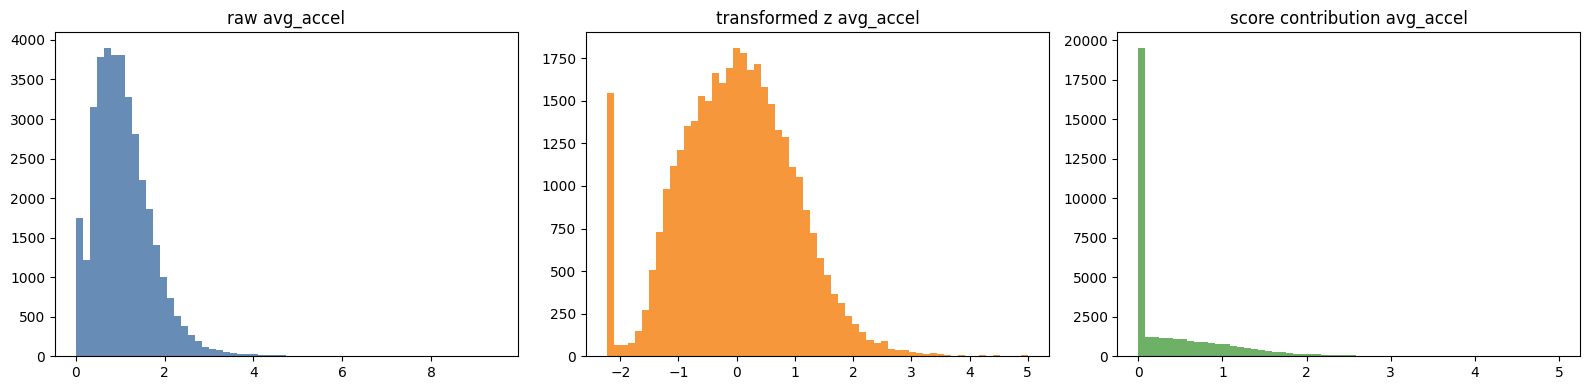

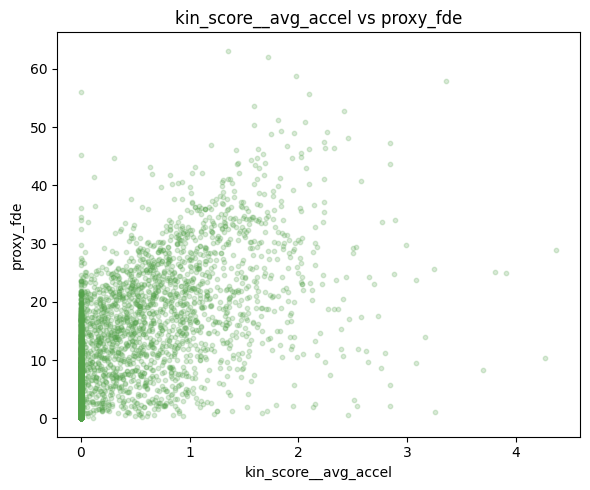

In [31]:
feature_name = 'avg_accel'
if feature_name not in KIN_FEATURES:
    raise ValueError(f"Feature {feature_name} is not in transformed kinematic features: {KIN_FEATURES}")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].hist(pd.to_numeric(df[feature_name], errors="coerce").dropna(), bins=60, color="#4c78a8", alpha=0.85)
axes[0].set_title(f"raw {feature_name}")
axes[1].hist(kin_z[feature_name].dropna(), bins=60, color="#f58518", alpha=0.85)
axes[1].set_title(f"transformed z {feature_name}")
axes[2].hist(kin_component_scores[feature_name].dropna(), bins=60, color="#54a24b", alpha=0.85)
axes[2].set_title(f"score contribution {feature_name}")
plt.tight_layout()

plot_df = eda_df[[f"kin_score__{feature_name}", ERROR_COLUMN]].dropna()
sample_df = plot_df.sample(min(len(plot_df), 4000), random_state=42)
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(sample_df[f"kin_score__{feature_name}"], sample_df[ERROR_COLUMN], s=10, alpha=0.22, color="#54a24b")
ax.set_title(f"kin_score__{feature_name} vs {ERROR_COLUMN}")
ax.set_xlabel(f"kin_score__{feature_name}")
ax.set_ylabel(ERROR_COLUMN)
plt.tight_layout()

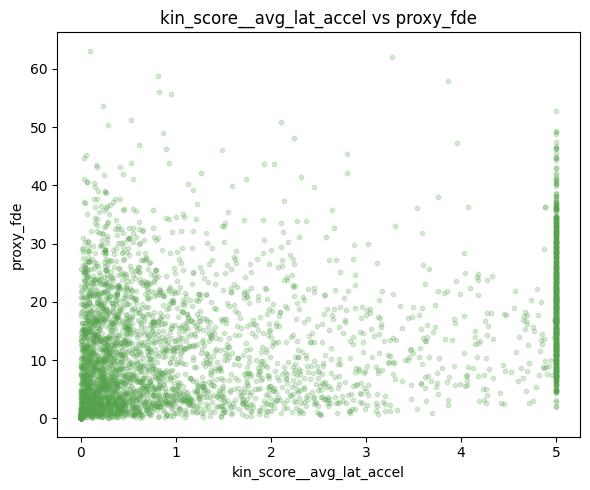

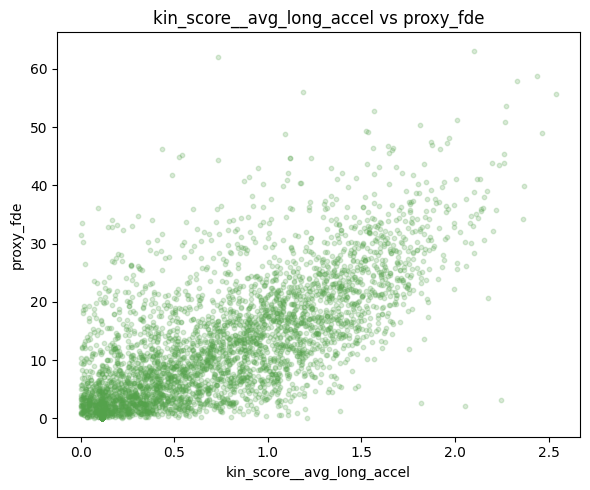

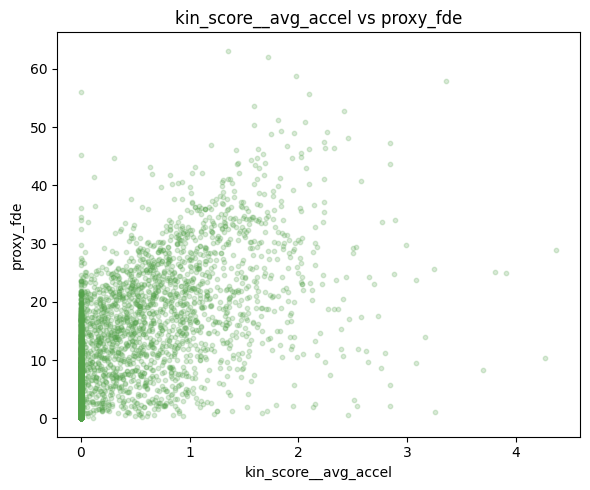

In [39]:
feature_name = 'avg_lat_accel'

plot_df = eda_df[[f"kin_score__{feature_name}", ERROR_COLUMN]].dropna()
sample_df = plot_df.sample(min(len(plot_df), 4000), random_state=42)
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(sample_df[f"kin_score__{feature_name}"], sample_df[ERROR_COLUMN], s=10, alpha=0.22, color="#54a24b")
ax.set_title(f"kin_score__{feature_name} vs {ERROR_COLUMN}")
ax.set_xlabel(f"kin_score__{feature_name}")
ax.set_ylabel(ERROR_COLUMN)
plt.tight_layout()

feature_name = 'avg_long_accel'

plot_df = eda_df[[f"kin_score__{feature_name}", ERROR_COLUMN]].dropna()
sample_df = plot_df.sample(min(len(plot_df), 4000), random_state=42)
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(sample_df[f"kin_score__{feature_name}"], sample_df[ERROR_COLUMN], s=10, alpha=0.22, color="#54a24b")
ax.set_title(f"kin_score__{feature_name} vs {ERROR_COLUMN}")
ax.set_xlabel(f"kin_score__{feature_name}")
ax.set_ylabel(ERROR_COLUMN)
plt.tight_layout()

feature_name = 'avg_accel'

plot_df = eda_df[[f"kin_score__{feature_name}", ERROR_COLUMN]].dropna()
sample_df = plot_df.sample(min(len(plot_df), 4000), random_state=42)
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(sample_df[f"kin_score__{feature_name}"], sample_df[ERROR_COLUMN], s=10, alpha=0.22, color="#54a24b")
ax.set_title(f"kin_score__{feature_name} vs {ERROR_COLUMN}")
ax.set_xlabel(f"kin_score__{feature_name}")
ax.set_ylabel(ERROR_COLUMN)
plt.tight_layout()

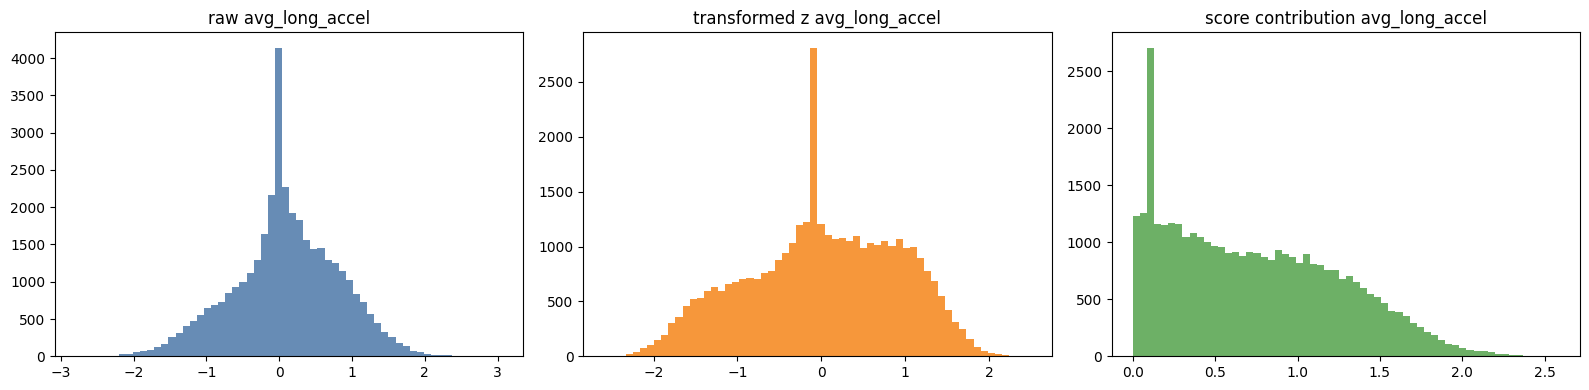

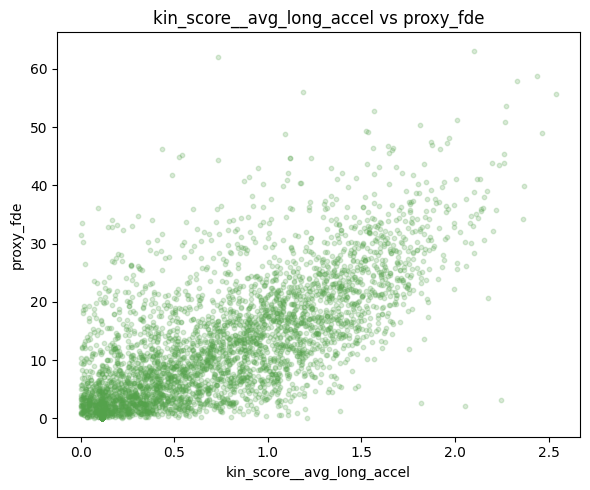

In [38]:
feature_name = CONFIG["feature_to_plot"]
if feature_name not in KIN_FEATURES:
    raise ValueError(f"Feature {feature_name} is not in transformed kinematic features: {KIN_FEATURES}")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].hist(pd.to_numeric(df[feature_name], errors="coerce").dropna(), bins=60, color="#4c78a8", alpha=0.85)
axes[0].set_title(f"raw {feature_name}")
axes[1].hist(kin_z[feature_name].dropna(), bins=60, color="#f58518", alpha=0.85)
axes[1].set_title(f"transformed z {feature_name}")
axes[2].hist(kin_component_scores[feature_name].dropna(), bins=60, color="#54a24b", alpha=0.85)
axes[2].set_title(f"score contribution {feature_name}")
plt.tight_layout()

plot_df = eda_df[[f"kin_score__{feature_name}", ERROR_COLUMN]].dropna()
sample_df = plot_df.sample(min(len(plot_df), 4000), random_state=42)
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(sample_df[f"kin_score__{feature_name}"], sample_df[ERROR_COLUMN], s=10, alpha=0.22, color="#54a24b")
ax.set_title(f"kin_score__{feature_name} vs {ERROR_COLUMN}")
ax.set_xlabel(f"kin_score__{feature_name}")
ax.set_ylabel(ERROR_COLUMN)
plt.tight_layout()

## Alternative Kinematic Difficulty Scores

In [20]:
weights = pd.Series(CONFIG["weighted_mean_weights"], dtype=float).reindex(KIN_FEATURES).fillna(1.0)
weights = weights / max(weights.sum(), 1e-6)

alt_scores = pd.DataFrame(index=eda_df.index)
for column in KIN_FEATURES:
    alt_scores[f"feature_score__{column}"] = kin_component_scores[column]

alt_scores["kin_mean"] = kin_component_scores.mean(axis=1)
alt_scores["kin_max"] = kin_component_scores.max(axis=1)
alt_scores["kin_top2_mean"] = np.sort(kin_component_scores.to_numpy(), axis=1)[:, -2:].mean(axis=1)
alt_scores["kin_weighted_mean"] = (kin_component_scores[KIN_FEATURES] * weights.values).sum(axis=1)

speed_family = [c for c in ["avg_speed", "max_speed", "displacement"] if c in kin_component_scores.columns]
turn_family = [c for c in ["heading_change_abs", "curvature_proxy", "heading_change_signed", "curvature_signed"] if c in kin_component_scores.columns]
dynamics_family = [c for c in ["avg_accel", "max_accel", "avg_jerk", "avg_long_accel", "avg_lat_accel", "avg_long_jerk", "avg_lat_jerk"] if c in kin_component_scores.columns]
alt_scores["speed_family_mean"] = kin_component_scores[speed_family].mean(axis=1)
alt_scores["turn_family_mean"] = kin_component_scores[turn_family].mean(axis=1)
alt_scores["dynamics_family_mean"] = kin_component_scores[dynamics_family].mean(axis=1)

try:
    from sklearn.decomposition import PCA
    pca = PCA(n_components=1, random_state=0)
    comp = pca.fit_transform(style_z[STYLE_FEATURES].to_numpy())[:, 0]
    alt_scores["style_pca1_abs"] = np.abs(comp - np.median(comp))
    pca_explained = float(pca.explained_variance_ratio_[0])
except Exception as exc:
    pca_explained = None
    print(f"PCA skipped: {exc}")

compare_cols = [
    "kalman_score",
    "trajectory_rarity_rank",
    "style_rarity_rank",
    "neighbor_count_score",
    "social_complexity",
    "social_complexity_rank",
    "kinematic_extremeness",
    "kinematic_extremeness_rank",
    "kinematic_extremeness_max",
    "kinematic_extremeness_top2",
    "difficulty_v1",
] + list(alt_scores.columns)

score_eval_df = pd.concat([eda_df, alt_scores], axis=1)
rows = []
for score_col in compare_cols:
    if score_col not in score_eval_df.columns:
        continue
    row = summarize_score(score_eval_df, score_col, ERROR_COLUMN)
    if row is not None:
        rows.append(row)
score_results = pd.DataFrame(rows).sort_values(["spearman", "top20_error_capture"], ascending=[False, False])
if pca_explained is not None:
    print(f"Style-space PCA-1 explained variance: {pca_explained:.3f}")
display(score_results)

Style-space PCA-1 explained variance: 0.545


,score_column,spearman,top20_error_capture,easy_mean_error,hard_mean_error,hard_over_easy_uplift
0,kalman_score,0.838746,0.749523,3.581299,26.591458,23.010159
19,feature_score__avg_long_accel,0.698480,0.601309,4.827843,23.662394,18.834551
13,feature_score__avg_accel,0.633631,0.576220,6.711044,23.124225,16.413181
35,dynamics_family_mean,0.559238,0.451595,4.561573,20.499110,15.937536
21,feature_score__avg_lat_accel,0.376317,0.416553,8.283538,19.850402,11.566864
14,feature_score__max_accel,0.365664,0.314699,8.579966,16.445722,7.865756
20,feature_score__max_abs_long_accel,0.345074,0.300382,8.890409,15.971575,7.081166
15,feature_score__avg_jerk,0.321551,0.346332,9.504520,17.248001,7.743481
22,feature_score__max_abs_lat_accel,0.305342,0.409599,10.163895,19.007943,8.844048
25,feature_score__avg_lat_jerk,0.299697,0.316062,8.870536,16.784961,7.914425


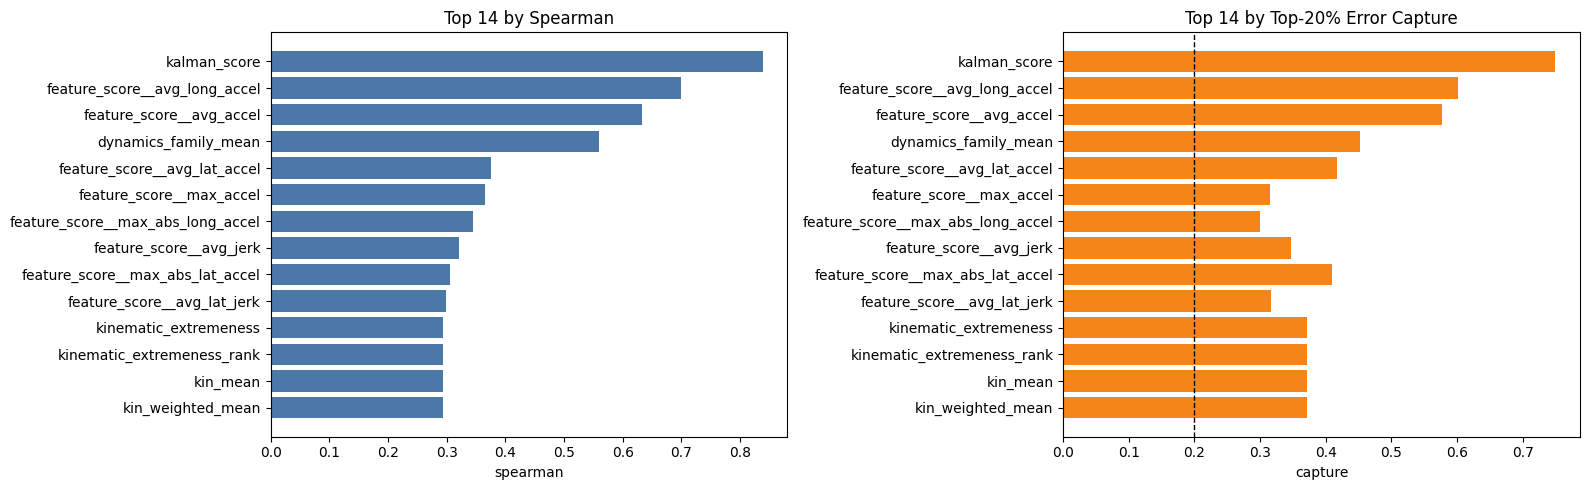

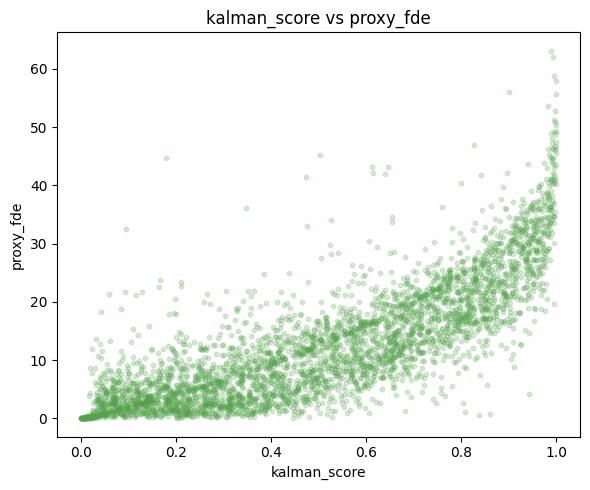

In [21]:
top_n = min(14, len(score_results))
top_scores = score_results.head(top_n)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].barh(top_scores["score_column"], top_scores["spearman"], color="#4c78a8")
axes[0].invert_yaxis()
axes[0].set_title(f"Top {top_n} by Spearman")
axes[0].set_xlabel("spearman")

axes[1].barh(top_scores["score_column"], top_scores["top20_error_capture"], color="#f58518")
axes[1].invert_yaxis()
axes[1].axvline(0.20, color="black", linestyle="--", linewidth=1)
axes[1].set_title(f"Top {top_n} by Top-20% Error Capture")
axes[1].set_xlabel("capture")
plt.tight_layout()

selected_score = top_scores.iloc[0]["score_column"] if len(top_scores) else "kinematic_extremeness"
plot_df = score_eval_df[[selected_score, ERROR_COLUMN]].dropna().sample(min(len(score_eval_df), 4000), random_state=42)
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(plot_df[selected_score], plot_df[ERROR_COLUMN], s=10, alpha=0.22, color="#54a24b")
ax.set_title(f"{selected_score} vs {ERROR_COLUMN}")
ax.set_xlabel(selected_score)
ax.set_ylabel(ERROR_COLUMN)
plt.tight_layout()

## Style Cluster EDA

,style_cluster_id,count,fraction,avg_speed_mean,avg_speed_std,max_speed_mean,max_speed_std,avg_accel_mean,avg_accel_std,max_accel_mean,max_accel_std,avg_jerk_mean,avg_jerk_std,avg_long_accel_mean,avg_long_accel_std,max_abs_long_accel_mean,max_abs_long_accel_std,avg_lat_accel_mean,avg_lat_accel_std,max_abs_lat_accel_mean,max_abs_lat_accel_std,avg_long_jerk_mean,avg_long_jerk_std,max_abs_long_jerk_mean,max_abs_long_jerk_std,avg_lat_jerk_mean,avg_lat_jerk_std,max_abs_lat_jerk_mean,max_abs_lat_jerk_std,heading_change_signed_mean,heading_change_signed_std,heading_change_abs_mean,heading_change_abs_std,displacement_mean,displacement_std,path_length_mean,path_length_std,curvature_proxy_mean,curvature_proxy_std,curvature_signed_mean,curvature_signed_std,trajectory_type_mean,trajectory_type_std,trajectory_rarity_mean,trajectory_rarity_std,style_rarity_mean,style_rarity_std,kinematic_extremeness_mean,kinematic_extremeness_std,kinematic_extremeness_max_mean,kinematic_extremeness_max_std,kinematic_extremeness_top2_mean,kinematic_extremeness_top2_std,social_complexity_mean,social_complexity_std,difficulty_v1_mean,difficulty_v1_std
0,0,6682,0.182240,3.709036,3.245756,6.051420,3.771528,1.197038,0.739238,5.328435,5.359613,4.145644,3.397430,0.268794,0.711088,4.866462,5.338074,-0.382636,0.468061,1.862133,2.139201,-0.072105,0.508963,27.849973,42.038814,-0.037813,0.280575,10.821423,18.111129,-2.239354,2.521337,5.678116,7.233645,21.717955,18.896769,22.673182,19.134258,9.489100,34.254705,-2.993707,13.585683,2.993714,2.283124,2.068435,1.012368,1.702433,0.000000e+00,1.284601,0.383579,4.886107,0.416310,4.752527,0.575745,0.286379,0.328652,0.800801,0.063411
1,1,23142,0.631157,8.250414,4.256176,9.995429,3.959687,0.982645,0.591976,3.868525,5.883844,3.936482,3.608207,-0.005012,0.707471,3.615533,5.826086,0.001689,0.092367,1.158548,1.616535,-0.069205,0.474060,22.010324,53.532391,-0.000753,0.157796,9.116889,15.311015,-0.001681,0.130029,0.564050,2.046092,48.882199,25.178269,48.949831,25.111791,0.180146,3.814481,-0.000088,0.007668,1.127949,0.740646,0.578319,0.713208,0.460201,1.665371e-16,0.456212,0.346263,1.881581,1.180641,1.627652,1.045560,0.245503,0.311981,0.556528,0.075616
2,2,6842,0.186603,3.951658,3.464750,6.188265,3.898416,1.241712,0.810968,5.665637,6.269455,4.402935,4.054003,0.270104,0.687999,5.063056,6.236007,0.446869,0.532516,2.106442,2.490810,-0.117051,0.559726,29.743358,52.655901,0.059289,0.331531,12.472909,21.010654,2.268220,2.566819,5.779605,7.418868,23.034927,20.151204,24.077655,20.411379,8.752220,30.584751,2.827810,12.146669,3.820374,3.027338,2.006504,1.025967,1.678770,0.000000e+00,1.323672,0.395751,4.911679,0.369090,4.776302,0.537010,0.269984,0.313951,0.748401,0.063772


,avg_speed,avg_accel,avg_jerk,displacement,heading_change_signed,curvature_signed,avg_long_accel,avg_lat_accel
style_cluster_id,,,,,,,,
0,-1.044198,0.145125,-0.013296,-1.336804,-4.549218,-2.102424,0.251733,-2.588976
1,0.167714,-0.114440,0.030425,0.135046,0.002600,0.000165,-0.116839,0.035564
2,-1.015252,0.203231,0.047112,-1.326224,4.553872,2.119343,0.243338,2.699747


,proxy_fde,difficulty_v1,kinematic_extremeness,social_complexity
style_cluster_id,,,,
0,15.283095,0.800801,1.284601,0.286379
1,10.933607,0.556528,0.456212,0.245503
2,15.330501,0.748401,1.323672,0.269984


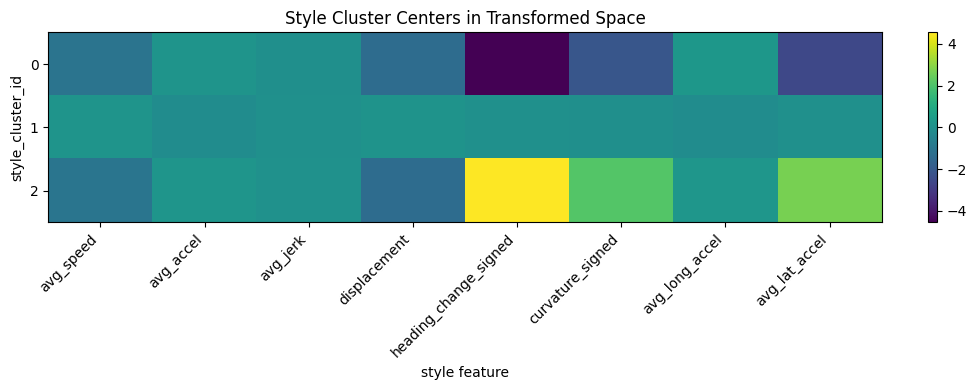

In [22]:
cluster_summary_key = "style_cluster_summary_train" if CONFIG["split"] == "train" else "style_cluster_summary_eval"
cluster_summary = pd.DataFrame(metadata.get(cluster_summary_key, []))
display(cluster_summary.sort_values("style_cluster_id"))

cluster_centers = pd.DataFrame(metadata.get("style_cluster_centers_transformed", []), columns=STYLE_FEATURES) if metadata.get("style_cluster_centers_transformed") else pd.DataFrame()
if not cluster_centers.empty:
    cluster_centers.index.name = "style_cluster_id"
    display(cluster_centers)
    fig, ax = plt.subplots(figsize=(10, 4))
    im = ax.imshow(cluster_centers.values, aspect="auto", cmap="viridis")
    ax.set_title("Style Cluster Centers in Transformed Space")
    ax.set_xlabel("style feature")
    ax.set_ylabel("style_cluster_id")
    ax.set_xticks(range(len(cluster_centers.columns)), cluster_centers.columns, rotation=45, ha="right")
    ax.set_yticks(range(len(cluster_centers.index)), cluster_centers.index)
    plt.colorbar(im, ax=ax, fraction=0.046)
    plt.tight_layout()

cluster_error = score_eval_df.groupby("style_cluster_id")[[ERROR_COLUMN, "difficulty_v1", "kinematic_extremeness", "social_complexity"]].mean()
display(cluster_error)

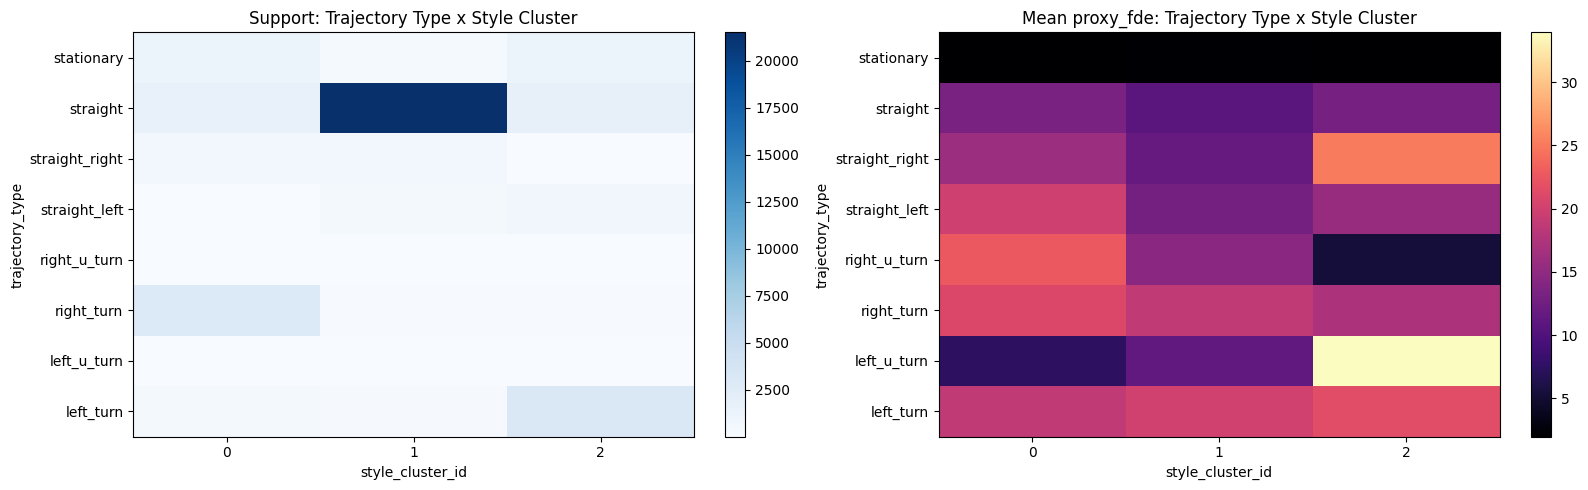

In [27]:
type_support = score_eval_df.pivot_table(index="trajectory_type", columns="style_cluster_id", values="scenario_id", aggfunc="count", fill_value=0)
type_error = score_eval_df.pivot_table(index="trajectory_type", columns="style_cluster_id", values=ERROR_COLUMN, aggfunc="mean")
type_support.index = [TRAJECTORY_LABELS.get(int(idx), str(idx)) for idx in type_support.index]
type_error.index = [TRAJECTORY_LABELS.get(int(idx), str(idx)) for idx in type_error.index]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
im0 = axes[0].imshow(type_support.values, aspect="auto", cmap="Blues")
axes[0].set_title("Support: Trajectory Type x Style Cluster")
axes[0].set_xlabel("style_cluster_id")
axes[0].set_ylabel("trajectory_type")
axes[0].set_xticks(range(len(type_support.columns)), type_support.columns)
axes[0].set_yticks(range(len(type_support.index)), type_support.index)
plt.colorbar(im0, ax=axes[0], fraction=0.046)

im1 = axes[1].imshow(type_error.fillna(np.nan).values, aspect="auto", cmap="magma")
axes[1].set_title(f"Mean {ERROR_COLUMN}: Trajectory Type x Style Cluster")
axes[1].set_xlabel("style_cluster_id")
axes[1].set_ylabel("trajectory_type")
axes[1].set_xticks(range(len(type_error.columns)), type_error.columns)
axes[1].set_yticks(range(len(type_error.index)), type_error.index)
plt.colorbar(im1, ax=axes[1], fraction=0.046)
plt.tight_layout()

In [28]:
representative_rows = []
for cluster_id in sorted(score_eval_df["style_cluster_id"].dropna().astype(int).unique()):
    cluster_df = score_eval_df[score_eval_df["style_cluster_id"] == cluster_id].copy()
    if cluster_df.empty:
        continue
    if not cluster_centers.empty and cluster_id < len(cluster_centers):
        center = cluster_centers.iloc[cluster_id].to_numpy(dtype=float)
    else:
        center = style_z.loc[cluster_df.index, STYLE_FEATURES].mean(axis=0).to_numpy(dtype=float)
    vectors = style_z.loc[cluster_df.index, STYLE_FEATURES].to_numpy(dtype=float)
    dists = np.linalg.norm(vectors - center[None, :], axis=1)
    cluster_df = cluster_df.assign(cluster_distance=dists)
    nearest = cluster_df.nsmallest(3, "cluster_distance")[["scenario_id", "center_objects_id", ERROR_COLUMN, "trajectory_type", "style_cluster_id", "cluster_distance"]].copy()
    hardest = cluster_df.nlargest(3, ERROR_COLUMN)[["scenario_id", "center_objects_id", ERROR_COLUMN, "trajectory_type", "style_cluster_id"]].copy()
    easiest = cluster_df.nsmallest(3, ERROR_COLUMN)[["scenario_id", "center_objects_id", ERROR_COLUMN, "trajectory_type", "style_cluster_id"]].copy()
    nearest["mode"] = "nearest"
    hardest["mode"] = "hardest"
    easiest["mode"] = "easiest"
    representative_rows.extend([nearest, hardest, easiest])

representatives = pd.concat(representative_rows, ignore_index=True) if representative_rows else pd.DataFrame()
if not representatives.empty:
    representatives["trajectory_label"] = representatives["trajectory_type"].map(lambda x: TRAJECTORY_LABELS.get(int(x), str(x)))
display(representatives.sort_values(["style_cluster_id", "mode", ERROR_COLUMN], ascending=[True, True, False]))

,scenario_id,center_objects_id,proxy_fde,trajectory_type,style_cluster_id,cluster_distance,mode,trajectory_label
8,236a6f78-3415-4b59-b0b6-129a490bd280,121232,0.003275,0,0,NaN,easiest,stationary
7,071b846d-92a9-4938-8f18-f16260cbf9fc,9129,0.002201,0,0,NaN,easiest,stationary
6,dd351edd-7795-407f-ba80-e1ada016c171,24995,0.001221,0,0,NaN,easiest,stationary
3,29d8da98-8046-474c-8c1c-1e3e7efe1394,57356,62.073833,1,0,NaN,hardest,straight
4,175b90dc-d3d1-4292-8a99-f09d62935952,124976,61.929642,0,0,NaN,hardest,stationary
5,c6a16b4e-d453-40ae-9bca-9c85f840ea3d,39373,60.579430,5,0,NaN,hardest,right_turn
2,bff66e32-9a5c-43e4-a7d2-9a9f3db74e36,45826,21.218603,1,0,1.405191,nearest,straight
1,cc6111b0-2f07-4866-b8ef-bba98143b7cc,15562,17.908489,1,0,1.257087,nearest,straight
0,5467d6d3-dfe0-45a0-8d5c-6139dd409368,48033,11.749703,5,0,1.037371,nearest,right_turn
17,91997fcc-2b30-4392-addc-8a1957722576,9488,0.002595,0,1,NaN,easiest,stationary


## Visualize Representative Style Samples

In [ ]:
candidate_scenario_id = CONFIG["scenario_id"]

if candidate_scenario_id is None:
    if representatives.empty:
        raise ValueError("No representative rows available. Check the loaded analysis table first.")
    cluster_id = CONFIG["cluster_id"]
    mode = CONFIG["example_mode"]
    rank = CONFIG["example_rank"]
    subset = representatives[(representatives["style_cluster_id"] == cluster_id) & (representatives["mode"] == mode)].reset_index(drop=True)
    if subset.empty:
        raise ValueError(f"No rows for cluster={cluster_id}, mode={mode}")
    rank = min(rank, len(subset) - 1)
    chosen = subset.iloc[rank]
    candidate_scenario_id = chosen["scenario_id"]
else:
    chosen = score_eval_df[score_eval_df["scenario_id"] == candidate_scenario_id].iloc[0]

scenario_split = resolve_split_name(CONFIG["dataset"], CONFIG["split"])
bundle = load_scenario_by_id(
    CONFIG["dataset"],
    candidate_scenario_id,
    split=scenario_split,
    dataset_root_override=CONFIG["dataset_root_override"],
)
print(f"Resolved scenario key: {bundle['scenario_key']}")
scenario = bundle["scenario"]
fig, ax = plot_scenario(
    scenario,
    dataset=CONFIG["dataset"],
    view_radius=CONFIG["view_radius"],
    show_track_ids=CONFIG["show_track_ids"],
)
plt.show()

display(
    score_eval_df[score_eval_df["scenario_id"] == candidate_scenario_id][[
        "scenario_id",
        "center_objects_id",
        "trajectory_type",
        "style_cluster_id",
        "kalman_score",
        "kinematic_extremeness",
        "kinematic_extremeness_max",
        "kinematic_extremeness_top2",
        "social_complexity",
        "difficulty_v1",
        ERROR_COLUMN,
    ]].sort_values(ERROR_COLUMN, ascending=False).head(20)
)

display(pd.Series(chosen))